# Q-Learning vs Double Q-Learning: Overestimation Bias on A-B MDP

This notebook compares Q-Learning and Double Q-Learning on the A-B MDP environment, which is designed to highlight the maximization bias problem that Q-Learning suffers from.

In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Add parent directory to sys.path for imports
sys.path.insert(0, os.path.abspath(".."))

from algorithms.q_learning import q_learning
from algorithms.double_q_learning import double_q_learning
from a_b_mdp_env import ABMDPEnv
from plot_utils import plot_result, calculate_action_left_percentage

## A-B MDP Environment Overview

The A-B MDP is a classic example from Sutton & Barto that demonstrates the **maximization bias** problem in Q-Learning:

- **State A** (start): Two choices:
  - Action Left → State B (reward = 0)
  - Action Right → Terminal (reward = 0)
  
- **State B**: All actions transition to Terminal with stochastic reward ~ N(-0.1, 1.0)

**Optimal Policy**: A → Right (expected value = 0)

**The Problem**: Due to noise in State B rewards, some actions occasionally have positive Q-values. Q-Learning's greedy max operation can be biased upward, leading it to overestimate Q(A, Left) and prefer the suboptimal Left action.

**Double Q-Learning Solution**: By decoupling the action selection from value estimation (using Q1 and Q2), it avoids this bias.

In [35]:
# Initialize the A-B MDP environment
env = ABMDPEnv(num_b_actions=50, mean_b_reward=-0.1, std_b_reward=1.5)

# Hyperparameters
seed = 27082026
gamma = 1.0  # Undiscounted return
max_episodes = 10000
step_size = 0.1
epsilon = 0.1  # Constant epsilon for exploration

print(f"Environment: A-B MDP")
print(f"State space: {env.observation_space.n} states")
print(f"Action space: {env.action_space.n} actions")
print(f"Max episodes: {max_episodes}")
print(f"Learning rate (alpha): {step_size}")
print(f"Epsilon (exploration): {epsilon}")

Environment: A-B MDP
State space: 3 states
Action space: 50 actions
Max episodes: 10000
Learning rate (alpha): 0.1
Epsilon (exploration): 0.1


In [36]:
# Generate seeds for reproducible runs with different initializations
seed_rng = np.random.default_rng(seed)
num_runs = 20
seeds = [seed_rng.integers(0, 100000) for _ in range(num_runs)]

print(f"Running {num_runs} independent experiments...")

Running 20 independent experiments...


In [ ]:
## Run Q-Learning

print("Running Q-Learning...")
q_learning_results = {
    "num_steps": [],
    "action_left_count": [],
    "cumulative_reward": [],
    "avg_reward": []
}

for i, s in enumerate(seeds):
    Q, history = q_learning(env, step_size=step_size, gamma=gamma, 
                            epsilon=epsilon, epsilon_decay_rate=None,  # No decay
                            max_episodes=max_episodes, seed=s)
    q_learning_results["num_steps"].append(history["num_steps"])
    q_learning_results["action_left_count"].append(history["action_left_count"])
    q_learning_results["cumulative_reward"].append(history["cumulative_reward"])
    q_learning_results["avg_reward"].append(history["avg_reward"])
    if (i + 1) % 5 == 0:
        print(f"  Completed {i + 1}/{num_runs} runs")

print("Q-Learning completed!")

Running Q-Learning...
  Completed 5/20 runs
  Completed 10/20 runs
  Completed 15/20 runs
  Completed 20/20 runs
Q-Learning completed!


In [ ]:
## Run Double Q-Learning

print("Running Double Q-Learning...")
double_q_learning_results = {
    "num_steps": [],
    "action_left_count": [],
    "cumulative_reward": [],
    "avg_reward": []
}

for i, s in enumerate(seeds):
    Q1, Q2, history = double_q_learning(env, step_size=step_size, gamma=gamma,
                                        epsilon=epsilon, max_episodes=max_episodes, seed=s)
    double_q_learning_results["num_steps"].append(history["num_steps"])
    double_q_learning_results["action_left_count"].append(history["action_left_count"])
    double_q_learning_results["cumulative_reward"].append(history["cumulative_reward"])
    double_q_learning_results["avg_reward"].append(history["avg_reward"])
    if (i + 1) % 5 == 0:
        print(f"  Completed {i + 1}/{num_runs} runs")

print("Double Q-Learning completed!")

Running Double Q-Learning...
  Completed 5/20 runs
  Completed 10/20 runs
  Completed 15/20 runs
  Completed 20/20 runs
Double Q-Learning completed!


## Compare Results

We now visualize the key metrics that reveal the overestimation bias in Q-Learning and how Double Q-Learning addresses it.

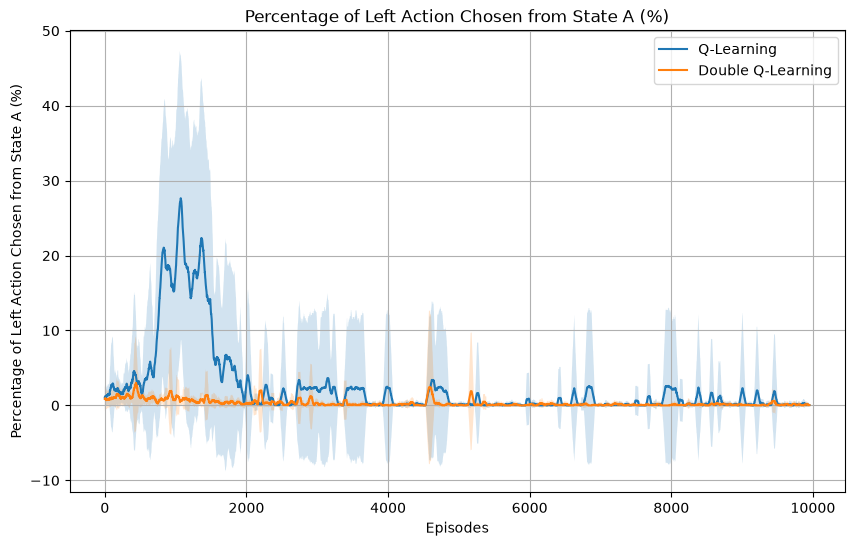

In [39]:
### 1. Action Left Percentage

# Calculate percentage of Left action chosen in State A
q_learning_left_pct = calculate_action_left_percentage(
    q_learning_results["action_left_count"],
    q_learning_results["num_steps"]
)
double_q_learning_left_pct = calculate_action_left_percentage(
    double_q_learning_results["action_left_count"],
    double_q_learning_results["num_steps"]
)

action_left_comparison = {
    "Q-Learning": q_learning_left_pct,
    "Double Q-Learning": double_q_learning_left_pct
}

plot_result(action_left_comparison, "Percentage of Left Action Chosen from State A (%)", smooth_window=50)

**Analysis**: Q-Learning has a high percentage choosing Left action throughout training, demonstrating overestimation bias. Double Q-Learning keeps this percentage low, correctly identifying that Left is suboptimal.

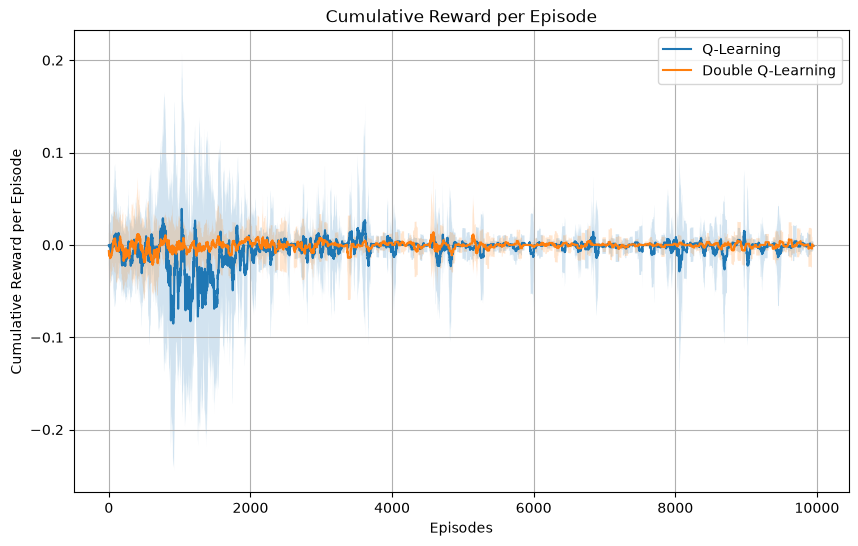

In [41]:
### 3. Cumulative Reward per Episode

cumulative_reward_comparison = {
    "Q-Learning": q_learning_results["cumulative_reward"],
    "Double Q-Learning": double_q_learning_results["cumulative_reward"]
}

plot_result(cumulative_reward_comparison, "Cumulative Reward per Episode", smooth_window=50)

**Analysis**: 
- **Q-Learning**: Negative cumulative reward throughout, indicating it frequently chooses Left (A → B → Terminal with reward ~ N(-0.1, 1.0))
- **Double Q-Learning**: Cumulative reward closer to 0, indicating it more frequently chooses Right (A → Terminal with reward = 0)

This is the direct consequence: Q-Learning's bias leads it to choose the suboptimal action and receive lower rewards.

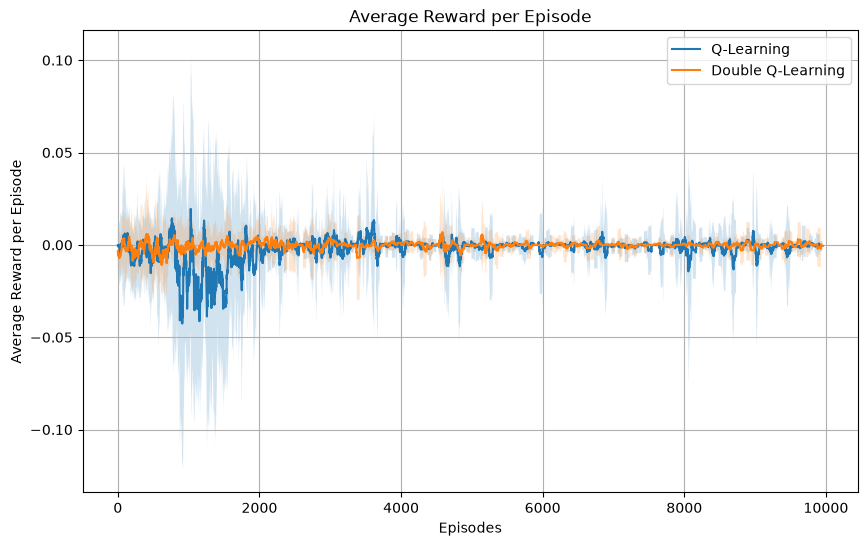

In [42]:
### 4. Average Reward per Episode

avg_reward_comparison = {
    "Q-Learning": q_learning_results["avg_reward"],
    "Double Q-Learning": double_q_learning_results["avg_reward"]
}

plot_result(avg_reward_comparison, "Average Reward per Episode", smooth_window=50)

**Analysis**: Average reward per step normalizes by episode length. Q-Learning's average reward is negative, confirming that even accounting for episode duration, it receives lower rewards due to the suboptimal Left action. Double Q-Learning maintains average reward closer to 0.

In [ ]:
## Summary Statistics

print("=" * 70)
print("SUMMARY STATISTICS")
print("=" * 70)

# Calculate statistics
q_learning_left_pct_final = [pct[-1] for pct in q_learning_left_pct]
double_q_learning_left_pct_final = [pct[-1] for pct in double_q_learning_left_pct]

q_learning_cum_reward = [np.sum(cr) for cr in q_learning_results["cumulative_reward"]]
double_q_learning_cum_reward = [np.sum(cr) for cr in double_q_learning_results["cumulative_reward"]]

q_learning_avg_reward = [np.mean(ar) for ar in q_learning_results["avg_reward"]]
double_q_learning_avg_reward = [np.mean(ar) for ar in double_q_learning_results["avg_reward"]]

# Print results
print("\n1. ACTION LEFT PERCENTAGE (final episodes, averaged over runs)")
print(f"   Q-Learning:           {np.mean(q_learning_left_pct_final):.2f}% ± {np.std(q_learning_left_pct_final):.2f}%")
print(f"   Double Q-Learning:    {np.mean(double_q_learning_left_pct_final):.2f}% ± {np.std(double_q_learning_left_pct_final):.2f}%")

print("\n2. TOTAL CUMULATIVE REWARD (sum across all episodes)")
print(f"   Q-Learning:           {np.mean(q_learning_cum_reward):.2f} ± {np.std(q_learning_cum_reward):.2f}")
print(f"   Double Q-Learning:    {np.mean(double_q_learning_cum_reward):.2f} ± {np.std(double_q_learning_cum_reward):.2f}")

print("\n3. AVERAGE REWARD PER EPISODE")
print(f"   Q-Learning:           {np.mean(q_learning_avg_reward):.4f} ± {np.std(q_learning_avg_reward):.4f}")
print(f"   Double Q-Learning:    {np.mean(double_q_learning_avg_reward):.4f} ± {np.std(double_q_learning_avg_reward):.4f}")

print("\n" + "=" * 70)

SUMMARY STATISTICS

1. ACTION LEFT PERCENTAGE (final episodes, averaged over runs)
   Q-Learning:           2.50% ± 10.90%
   Double Q-Learning:    0.00% ± 0.00%

2. Q-VALUE BIAS (final episodes, averaged over runs)
   Q-Learning:           -0.0931 ± 0.0362
   Double Q-Learning:    -0.2146 ± 0.0905

3. TOTAL CUMULATIVE REWARD (sum across all episodes)
   Q-Learning:           -28.61 ± 9.48
   Double Q-Learning:    -17.01 ± 11.21

4. AVERAGE REWARD PER EPISODE
   Q-Learning:           -0.0014 ± 0.0005
   Double Q-Learning:    -0.0009 ± 0.0006



## Conclusion

### Key Findings

1. **Overestimation Bias in Q-Learning**: The data clearly demonstrates that Q-Learning suffers from maximization bias on the A-B MDP task. It overestimates the value of the Left action, leading to suboptimal policy learning.

2. **Double Q-Learning Solution**: By maintaining two independent Q-value estimates and decoupling action selection from value estimation, Double Q-Learning successfully avoids the overestimation problem.

3. **Practical Consequences**:
   - Q-Learning: Chooses the suboptimal Left action frequently, resulting in negative cumulative and average rewards
   - Double Q-Learning: Correctly identifies Right as the optimal action, maintaining rewards close to 0 (the true optimal value)

### Why This Matters

The A-B MDP is a simple but powerful illustration of a fundamental problem in Q-Learning:
- Q-Learning uses **max** to select and evaluate the next action, which can overestimate due to noise
- Double Q-Learning addresses this by using separate learned estimates for action selection and evaluation
- This bias becomes more problematic in environments with:
  - Stochastic rewards
  - Large action spaces (more opportunities for max to overestimate)
  - Long horizons (errors compound)